In [5]:
import pandas as pd
# load data
df = pd.read_csv('ToyotaCorolla - MLR.csv')
# Display the first few rows of the dataframe
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [7]:
# displaying statistics of the dataframe
display(df.describe())
display(df.describe(include='object'))

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


,Fuel_Type
count,1436
unique,3
top,Petrol
freq,1264


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\cheli\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\cheli\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\cheli\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\cheli\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

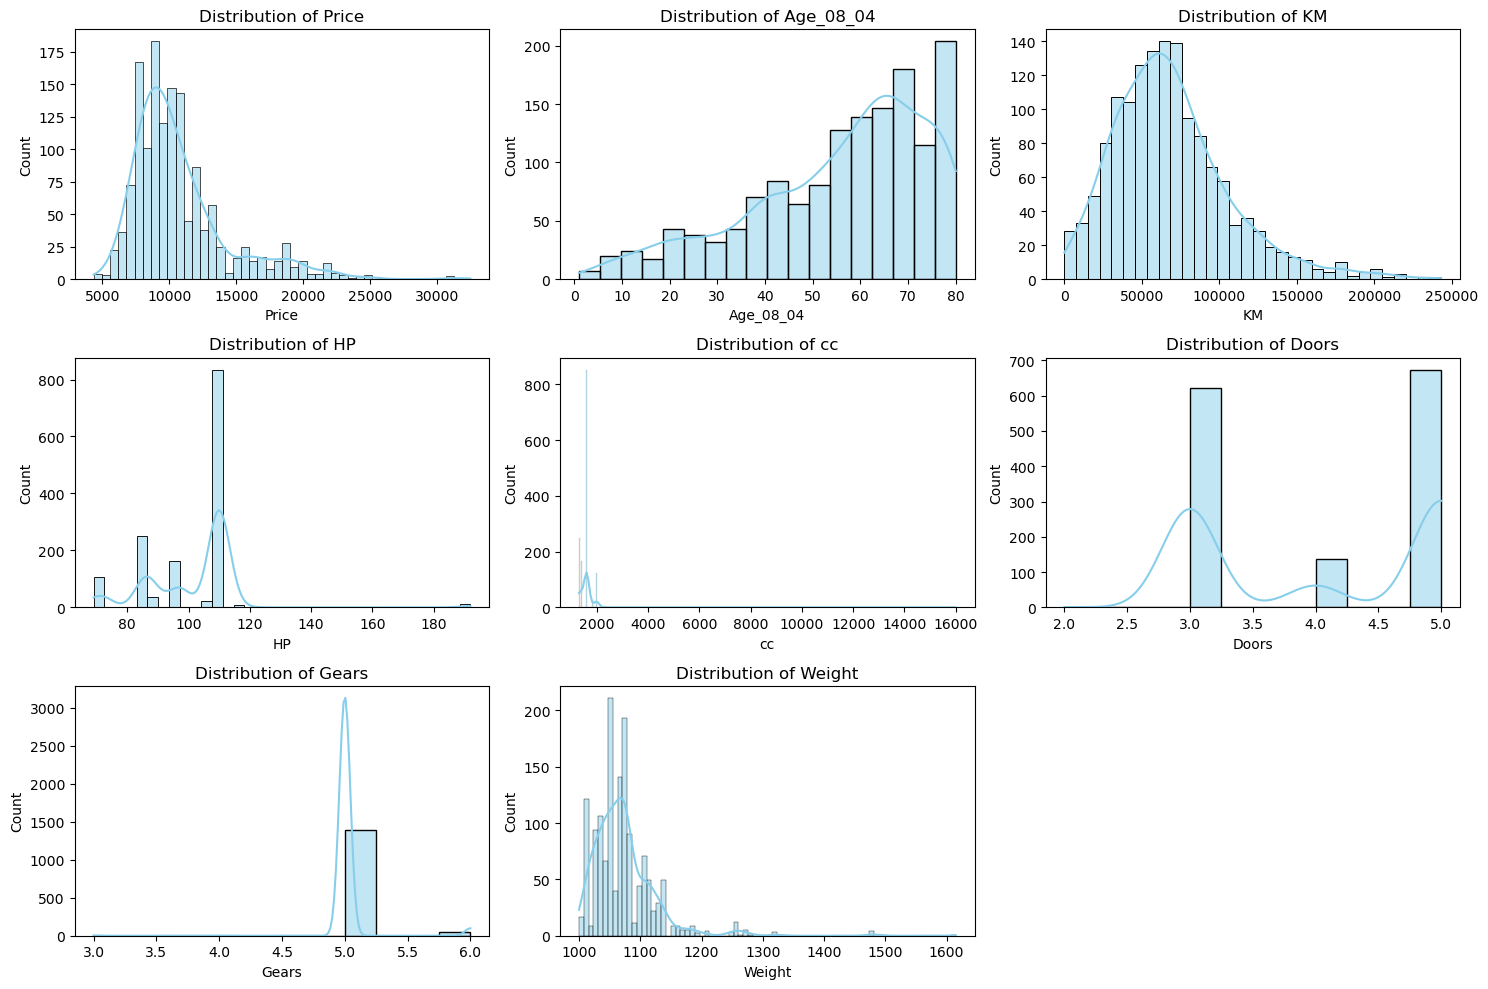

In [11]:
# Visualizing the distribution of numerical features
numerical_cols = ['Price', 'Age_08_04', 'KM', 'HP', 'cc', 'Doors', 'Gears', 'Weight']

plt.figure(figsize=(15, 10))
# crating the histograms for each numerical column
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True,color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

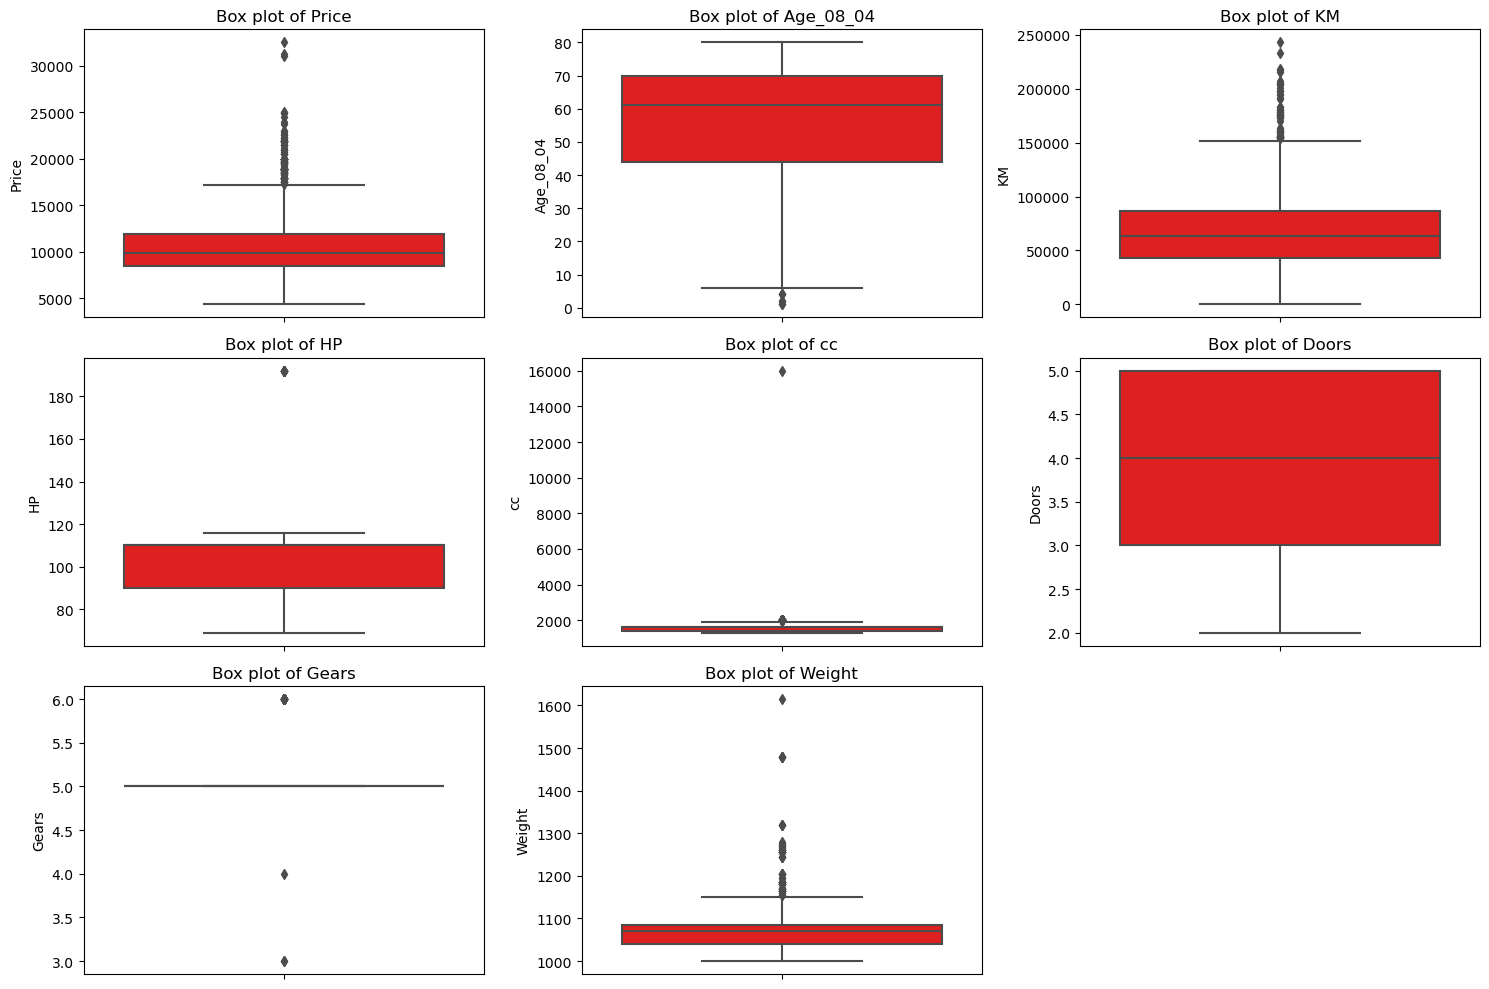

In [13]:
# Visualizing the box plots for numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col],color = 'Red')
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

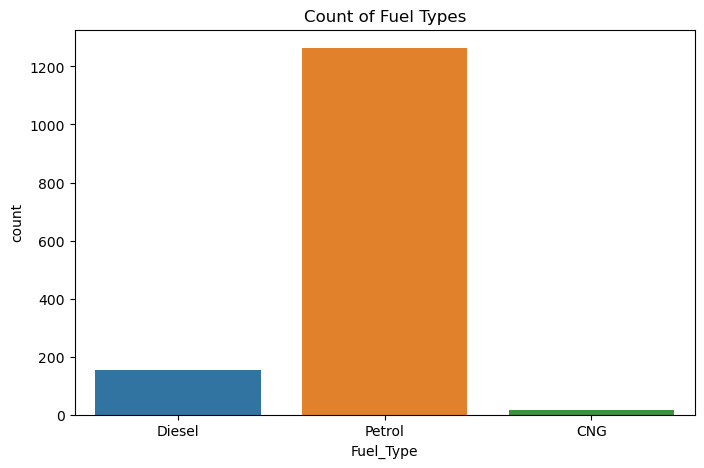

In [15]:
# Visualizing the count of categorical features
plt.figure(figsize=(8, 5))
sns.countplot(x='Fuel_Type', data=df)
plt.title('Count of Fuel Types')
plt.show()

C:\Users\cheli\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


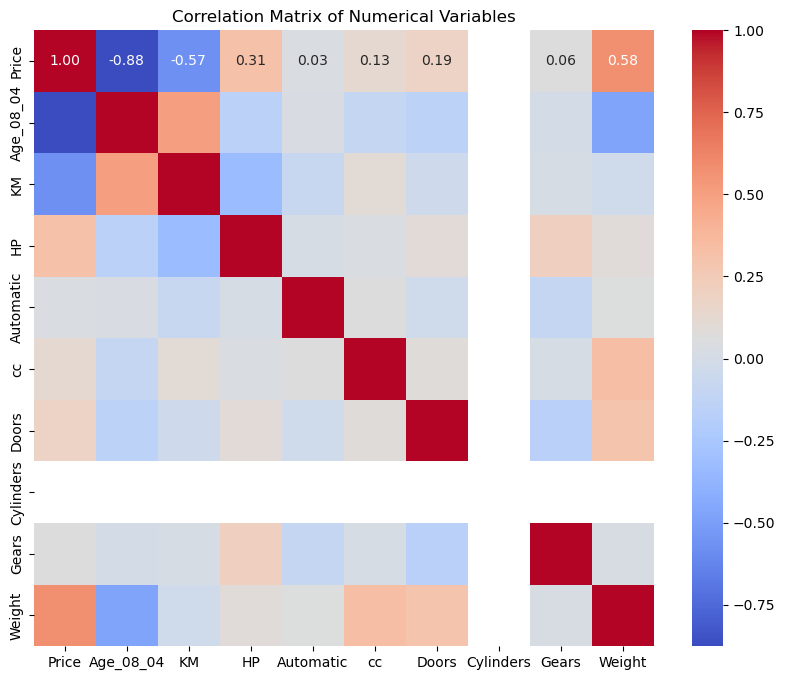

In [17]:
# Visualizing the correlation matrix of numerical features
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

In [19]:
# Converting categorical variable 'Fuel_Type' into dummy variables
fuel_type_dummies = pd.get_dummies(df['Fuel_Type'], prefix='Fuel_Type', drop_first=True)
df = pd.concat([df, fuel_type_dummies], axis=1)
df = df.drop('Fuel_Type', axis=1)
display(df.head())

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


In [21]:
# Selecting features and target variable
feature_columns = df.drop(['Price', 'Cylinders'], axis=1).columns
features = df[feature_columns]
display(features.head())

,Age_08_04,KM,HP,Automatic,cc,Doors,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,23,46986,90,0,2000,3,5,1165,True,False
1,23,72937,90,0,2000,3,5,1165,True,False
2,24,41711,90,0,2000,3,5,1165,True,False
3,26,48000,90,0,2000,3,5,1165,True,False
4,30,38500,90,0,2000,3,5,1170,True,False


In [23]:
# Splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Define the target variable and features
y = df['Price']
X = features
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1148, 10)
X_test shape: (288, 10)
y_train shape: (1148,)
y_test shape: (288,)


In [25]:
# Importing the Linear Regression model
from sklearn.linear_model import LinearRegression
# Creating and training the Linear Regression model
model = LinearRegression()
# Fitting the model to the training data
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
# Displaying the model coefficients and intercept
print("Model Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)

Model Coefficients: [-1.20830458e+02 -1.62314106e-02  1.40394788e+01  1.48830927e+02
 -3.03721946e-02 -6.03109744e+01  5.51600710e+02  2.58849583e+01
 -6.85487568e+01  1.37080891e+03]
Model Intercept: -14255.385993565298


In [29]:
# Making predictions on the test set and evaluating the model
from sklearn.metrics import mean_squared_error, r2_score
# Predicting the target variable for the test set
y_pred = model.predict(X_test)
# Calculating the Mean Squared Error (MSE) and R-squared (R2) score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
# Displaying the evaluation metrics
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")

Mean Squared Error (MSE): 2203043.823143704
R-squared (R2): 0.8348888040611082


In [31]:
# Importing the Lasso regression model
from sklearn.linear_model import Lasso
# Creating and training the Lasso regression model
# Setting the regularization parameter alpha
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [33]:
# Making predictions with the Lasso model and evaluating its performance
from sklearn.metrics import mean_squared_error, r2_score
# Predicting the target variable for the test set using Lasso model
y_pred_lasso = lasso_model.predict(X_test)
# Calculating the Mean Squared Error (MSE) and R-squared (R2) score for Lasso model
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
# Displaying the evaluation metrics for Lasso model
print(f"Lasso Model Mean Squared Error (MSE): {mse_lasso}")
print(f"Lasso Model R-squared (R2): {r2_lasso}")

Lasso Model Mean Squared Error (MSE): 2195387.2460865397
Lasso Model R-squared (R2): 0.8354626403967389


In [35]:
# Importing the Ridge regression model
from sklearn.linear_model import Ridge
# Creating and training the Ridge regression model
# Setting the regularization parameter alpha
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [37]:
# Making predictions with the Ridge model and evaluating its performance
from sklearn.metrics import mean_squared_error, r2_score
# Predicting the target variable for the test set using Ridge model
y_pred_ridge = ridge_model.predict(X_test)
# Calculating the Mean Squared Error (MSE) and R-squared (R2) score for Ridge model
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
# Displaying the evaluation metrics for Ridge model
print(f"Ridge Model Mean Squared Error (MSE): {mse_ridge}")
print(f"Ridge Model R-squared (R2): {r2_ridge}")

Ridge Model Mean Squared Error (MSE): 2199746.370233328
Ridge Model R-squared (R2): 0.8351359377712344


In [39]:
# Comparing the performance of Linear Regression, Lasso Regression, and Ridge Regression
print("--- Model Performance Comparison ---")
print(f"Linear Regression - MSE: {mse:.2f}, R2: {r2:.4f}")
print(f"Lasso Regression - MSE: {mse_lasso:.2f}, R2: {r2_lasso:.4f}")
print(f"Ridge Regression - MSE: {mse_ridge:.2f}, R2: {r2_ridge:.4f}")
# Interpretation of the results
print("\nInterpretation:")
print("Lower MSE indicates better prediction accuracy.")
print("Higher R2 indicates that a larger proportion of the variance in the target variable is explained by the model.")
print("\nComparison:")
# Comparing the MSE and R2 scores of the three models
if mse_lasso < mse and mse_lasso < mse_ridge:
    print("Lasso Regression has the lowest MSE, suggesting slightly better prediction accuracy.")
elif mse_ridge < mse and mse_ridge < mse_lasso:
    print("Ridge Regression has the lowest MSE, suggesting slightly better prediction accuracy.")
else:
    print("Linear Regression has a comparable or slightly lower MSE.")
# Comparing the R2 scores of the three models
if r2_lasso > r2 and r2_lasso > r2_ridge:
    print("Lasso Regression has the highest R2, indicating it explains slightly more variance in the target variable.")
elif r2_ridge > r2 and r2_ridge > r2_lasso:
    print("Ridge Regression has the highest R2, indicating it explains slightly more variance in the target variable.")
else:
    print("Linear Regression has a comparable or slightly higher R2.")

print("\nOverall, all three models perform similarly based on these metrics, with slight variations in MSE and R2.")

--- Model Performance Comparison ---
Linear Regression - MSE: 2203043.82, R2: 0.8349
Lasso Regression - MSE: 2195387.25, R2: 0.8355
Ridge Regression - MSE: 2199746.37, R2: 0.8351

Interpretation:
Lower MSE indicates better prediction accuracy.
Higher R2 indicates that a larger proportion of the variance in the target variable is explained by the model.

Comparison:
Lasso Regression has the lowest MSE, suggesting slightly better prediction accuracy.
Lasso Regression has the highest R2, indicating it explains slightly more variance in the target variable.

Overall, all three models perform similarly based on these metrics, with slight variations in MSE and R2.


In [ ]:
Interpretation of Linear Regression Coefficients (MLR)

In Multiple Linear Regression, each coefficient shows how the dependent variable changes when an independent variable increases by one unit, while keeping other variables constant.
     .Intercept (β₀): Predicted value of the dependent variable when all independent variables are 0. 
     .Positive coefficient: Increase in the independent variable increases the dependent variable. 
     .Negative coefficient: Increase in the independent variable decreases the dependent variable.
Example:
If the coefficient of Age = -120, it means when the car age increases by 1 unit, the car price decreases by 120 units, assuming other variables remain constant.

In [ ]:
1.What is Normalization & Standardization and how is it helpful?

Normalization & Standardization

Both are techniques to rescale features before applying machine learning models, especially models sensitive to feature scales (like regression, KNN, SVM, neural networks).

Normalization (Min-Max Scaling)
Rescales the values of a feature to a fixed range, typically [0, 1].

Standardization (Z-Score Scaling)
Transforms data to have mean = 0 and standard deviation = 1.
    .Prevents features with large values from dominating the model.
    .Improves training stability and convergence speed in gradient-based methods.
    .Ensures fair comparison between coefficients in regression.
    .Reduces numerical instability in matrix operations.

In [ ]:
2.What techniques can be used to address multicollinearity in multiple linear regression?
  Multicollinearity is when independent variables are highly correlated with each other, making it hard to interpret coefficients.
  Techniques:
   1.Remove highly correlated predictors
     Drop one of the variables that shows high correlation (correlation coefficient > 0.8 usually signals concern).
   2.Principal Component Analysis (PCA)
     Combine correlated features into uncorrelated principal components, then use them in regression.
   3.Regularization methods
     Ridge Regression (L2): Shrinks coefficients, reduces variance caused by multicollinearity.
     Lasso Regression (L1): Performs feature selection by driving some coefficients to zero.
   4.Variance Inflation Factor (VIF) check
    Calculate VIF for predictors. If VIF > 10, consider removing or transforming that variable.
   5.Domain knowledge feature selection
    Keep only the most meaningful features based on business/domain understanding.